In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
import koreanize_matplotlib

from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

In [2]:
df = pd.read_csv('course_final.csv')

In [3]:
df.head()

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


### 0. 각 단계별 이탈 구간이 심한 곳

In [4]:
stages = ['registered', 'viewed','explored']

df_funnel = df[stages].sum().reset_index()
df_funnel.columns = ['stages','user_count']

# 전체 유저 수
n = df_funnel.loc[0,'user_count']

df_funnel['step_conversion_rate'] = df_funnel['user_count'] / df_funnel['user_count'].shift(1)
df_funnel['cumulative_conversion_rate'] = df_funnel['user_count'] / n

df_funnel.loc[0,'step_conversion_rate'] = 1
df_funnel

,stages,user_count,step_conversion_rate,cumulative_conversion_rate
0,registered,533993,1.000000,1.000000
1,viewed,325361,0.609298,0.609298
2,explored,37584,0.115515,0.070383


In [5]:
import plotly.graph_objects as go

# https://simbbo-blog.tistory.com/185 참고
fig = go.Figure(go.Funnel(
    y=df_funnel['stages'],
    x=df_funnel['user_count'],
    textinfo="value+percent initial+percent previous",
    marker=dict(color=["#FF5733", "#FFC300", "#C70039", "#900C3F"]),
    hoverinfo = "y+x+percent initial+percent previous"
))

fig.update_layout(
    title='누적 생존율 및 단계별 전환율',
    yaxis_title='Stage'
)

fig.show()

1. explored에서 가장 많은 유저가 이탈함.

viewed -> explored의 전환율이 11% 가량으로 가장 많은 유저가 이탈하는 구간임

-> 이 부분에 대해서 중점적으로 보아야 하지 않을까.

### 1. Viewed의 초기 구간 이탈

In [6]:
df_viewed = df[df['viewed'] == 1]

df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

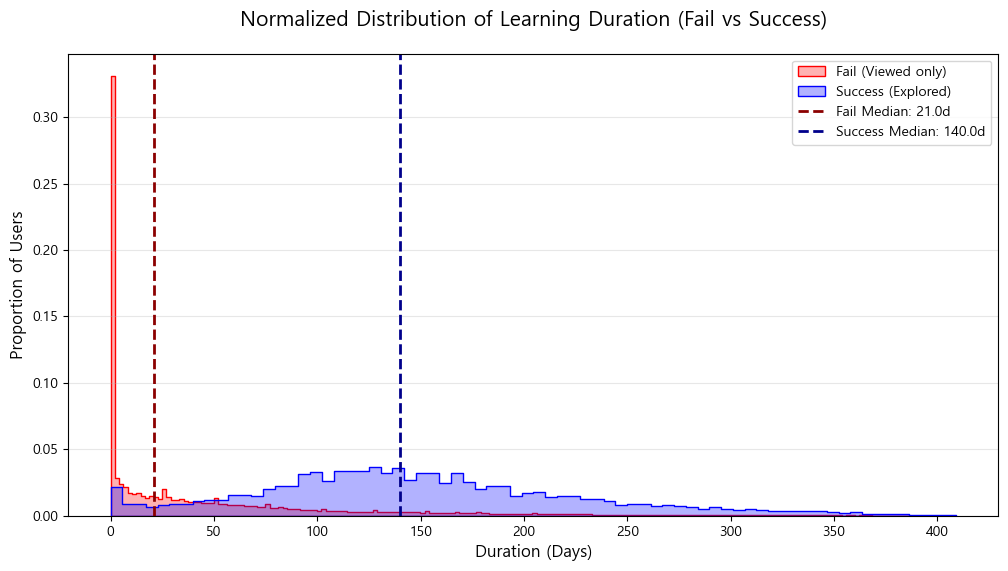

In [7]:
median_fail = df_fail_explored['duration'].median()
median_suc = df_suc_explored['duration'].median()

plt.figure(figsize=(12, 6))

# 성공/실패 그룹의 비율(Proportion) 비교
# common_norm=False를 해야 각 그룹별로 100% 기준이 잡힙니다.
sns.histplot(data=df_fail_explored, x='duration', color='red', label='Fail (Viewed only)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

sns.histplot(data=df_suc_explored, x='duration', color='blue', label='Success (Explored)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

# 중앙값 표시
plt.axvline(median_fail, color='darkred', linestyle='--', linewidth=2, label=f'Fail Median: {median_fail}d')
plt.axvline(median_suc, color='darkblue', linestyle='--', linewidth=2, label=f'Success Median: {median_suc}d')

# 그래프 디테일
plt.title('Normalized Distribution of Learning Duration (Fail vs Success)', fontsize=15, pad=20)
plt.xlabel('Duration (Days)', fontsize=12)
plt.ylabel('Proportion of Users', fontsize=12) # Y축이 이제 비율(0~1)로 바뀝니다.
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Viewed의 경우, 30% 이상이 초기에 이탈하는 것을 확인할 수 있음

- 단순히 그림만 보더라도, 통계 검정까지 갈 필요 없이 전체 수강일이 길 수록 강의를 열심히 수강하는 그룹이 늘어남

- explored까지 가려면 결국 초기 이탈을 어디에서 잡을 수 있을지를 확인해야 함

In [8]:
# viewed 그룹에서 어디에서 많이 이탈하는가
df_proportion = df_fail_explored.value_counts('duration').reset_index().sort_values('duration')
df_proportion['proportion'] = df_proportion['count'] / len(df_fail_explored)
df_proportion['fail_rate'] = 1 - df_proportion['proportion'].cumsum()
df_proportion

df_proportion['duration'] = df_proportion['duration'] + 1
start_point = pd.DataFrame({'duration':[0], 'fail_rate':[1.0]})
df_plot = pd.concat([start_point, df_proportion]).sort_values('duration').reset_index(drop = True)
df_plot.head(30)

,duration,fail_rate,count,proportion
0,0,1.000000,NaN,NaN
1,1,0.763174,68153.0,0.236826
2,2,0.690528,20906.0,0.072647
3,3,0.668886,6228.0,0.021642
4,4,0.653377,4463.0,0.015509
5,5,0.640190,3795.0,0.013187
6,6,0.628233,3441.0,0.011957
7,7,0.616307,3432.0,0.011926
8,8,0.604541,3386.0,0.011766
9,9,0.594332,2938.0,0.010209


강의 등록 후 마지막 활동일이 1,2에서 마지막에 기록되는 값이 존재.

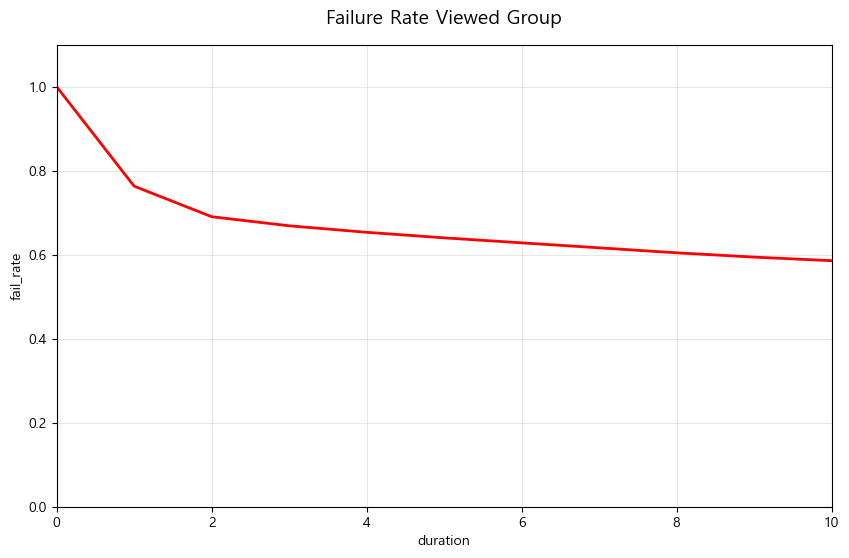

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

plt.xlim(0, 10)
plt.ylim(0, 1.1) 
plt.title('Failure Rate Viewed Group', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

이 부분은 x축만 전체로 변경한 코드. 참고용

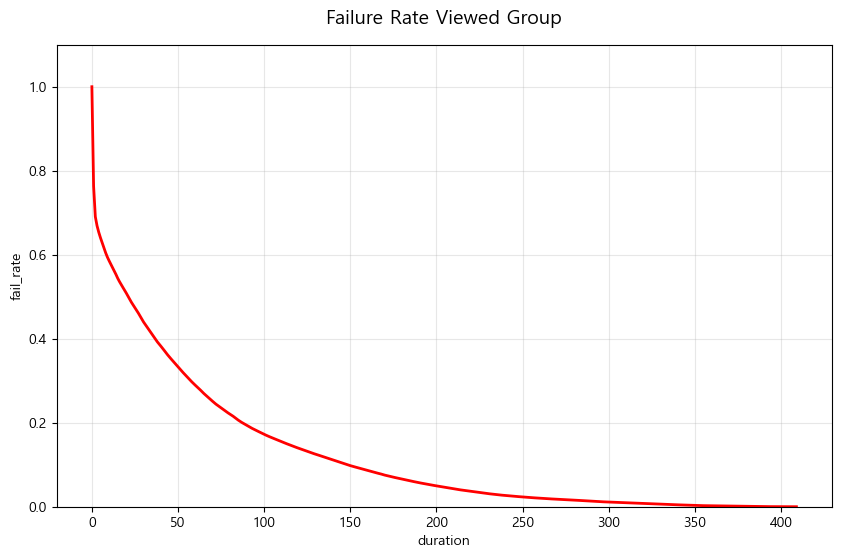

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

plt.ylim(0, 1.1) 
plt.title('Failure Rate Viewed Group', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

해석의 관점은 두 가지가 있을 것 같음.

1. 초기 이탈은 유저의 행동 정보가 쌓이기 이전이기 때문에 행동 정보로는 추측할 수 없다.

따라서, 단순히 이틀만에 32%가 빠져나가기 때문에 이 구간이 중요하다 까지를 보일 수는 있지만, 그 이유에 대한 액션은 추측할 수 밖에 없다.

2. 혹은 초기 이탈에 대해서, 단순히 duration이 2일 내 아무 행동도 하지 않은 유저의 수를 세서, 2일 동안 활동 정보가 아예 없다고 정의를 한다. -> 이것도 활동 데이터의 수가 적어서, 힘듦.

3. 수료자 그룹의 활동에 대한 cutoff를 기준으로 2일 동안 어떤 활동을 해야 한다는 기준을 세운다.

그럼 2일차 이전에 이탈한 그룹은 어떤 행동 패턴을 보이는가.

nevents        0.018964
ndays_act      0.018964
nplay_video    0.567160
nchapters      0.144112
dtype: float64

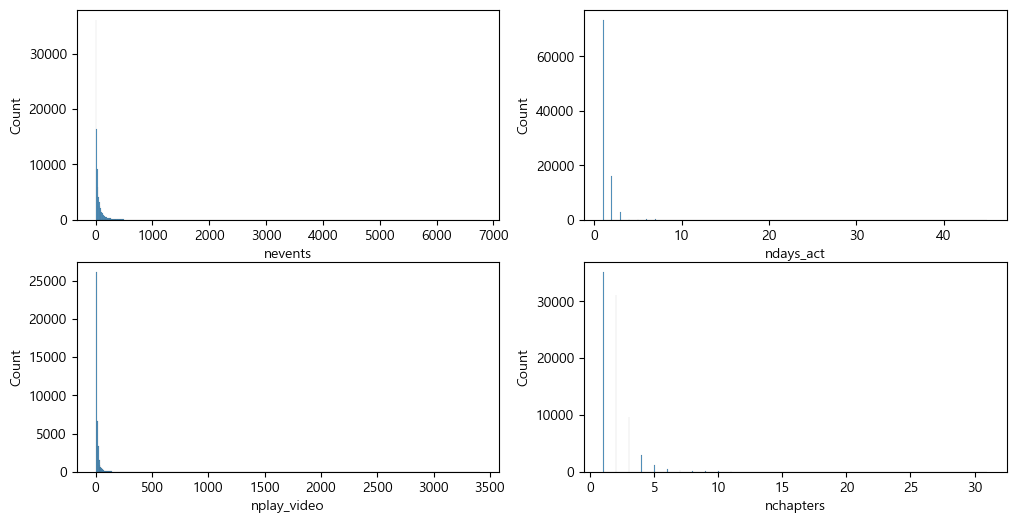

In [11]:
# df_2day만 추출
df_2day = df_fail_explored[df_fail_explored['duration'] <= 2]

fig, axs = plt.subplots(2,2 ,figsize = (12,6))

# nevents, ndays_act, nplay_video, nchapters 4가지에 대한 행동 패턴 시각화

for i, col in enumerate(['nevents','ndays_act','nplay_video','nchapters']):
    sns.histplot(df_2day[col], ax = axs[i // 2][i % 2])

# duration <= 2로 설정했을 때 ndays_act가 더 큰 모습을 보임
# 무튼 이 그래프는 보여드리면 안 될 듯. 지금 보여드리면 이 부분 가지고 난리를 치실 것 같다.

# nplay_video의 결측치 비율로 보았을 때, 초기 이탈은 nplay_video, nchapters로 확인하기는 어렵다.
# 결국 무언가의 행동 패턴을 nevents로 밖에는 판단할 수 없다는 얘기
df_2day[['nevents','ndays_act','nplay_video','nchapters']].isna().sum() / len(df_2day)

ndays_act와 (duration + 1)의 대소관계가 df_2day에서 어긋나는 데이터의 개수

-> 이것에 대한 판단도 필요할 듯. 우리가 이 초기 이탈을 사용할 거라면, ndays_act와 duration의 대소관계가 맞지 않는 것은 제거나 capping이 필요.

In [12]:
sum(df_viewed['ndays_act'] / (df_viewed['duration'] + 1) > 1)

4443

### 생각 1

단순히 (duration + 1) / ndays_act을 평균을 사용해서 며칠에 한 번 씩 들어오는지 계산하고, 

nevents / ndays_act를 계산해서 최소한 이 값 정도로는 무언가 액션이 있어야 한다의 기준을 제시한다.

이 코드는 nevents를 ndays_act로 나눠서, 일별 평균 클릭율이 explored와 viewed에 따라 우선 통계 검정으로 차이가 존재해야 의미 있게 활용할 수 있음.

(0.0, 200.0)

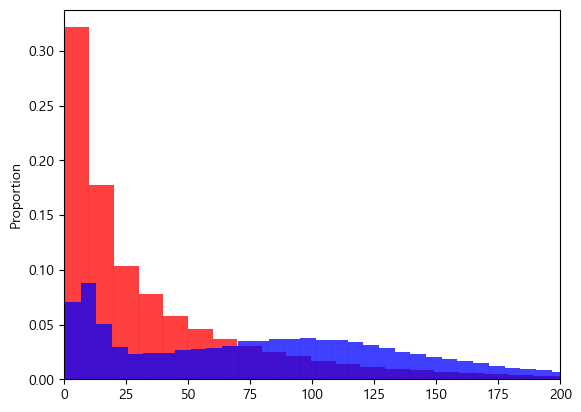

In [13]:
df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

sns.histplot(df_fail_explored['nevents'] / df_fail_explored['ndays_act'], color = 'red', stat = 'proportion')
sns.histplot(df_suc_explored['nevents'] / df_suc_explored['ndays_act'], color = 'blue', stat = 'proportion')

plt.xlim(0,200)

In [14]:
from scipy import stats

# 1. 두 그룹의 변수 정의 (결측치가 있다면 dropna()를 꼭 해주세요)
fail_density = (df_fail_explored['nevents'] / df_fail_explored['ndays_act']).dropna()
suc_density = (df_suc_explored['nevents'] / df_suc_explored['ndays_act']).dropna()

# 2. 맨-휘트니 U 검정 실행 (대립가설: suc_density가 fail_density보다 크다)
stat, p_val = stats.mannwhitneyu(suc_density, fail_density, alternative='greater')

# 3. 각 그룹의 중앙값 확인 (보고서 작성용)
print(f"이탈 그룹(Fail) 일평균 클릭수 중앙값: {fail_density.median():.1f}회")
print(f"수료 그룹(Success) 일평균 클릭수 중앙값: {suc_density.median():.1f}회")
print("-" * 30)
print(f"Mann-Whitney U 통계량: {stat}")
print(f"P-value: {p_val}")

if p_val < 0.05:
    print("결론: 두 그룹 간의 일평균 몰입도(클릭수)는 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론: 통계적으로 유의미한 차이가 없습니다.")

이탈 그룹(Fail) 일평균 클릭수 중앙값: 20.3회
수료 그룹(Success) 일평균 클릭수 중앙값: 83.8회
------------------------------
Mann-Whitney U 통계량: 7936023760.0
P-value: 0.0
결론: 두 그룹 간의 일평균 몰입도(클릭수)는 통계적으로 유의미한 차이가 있습니다.


In [15]:
# stat은 아까 구한 Mann-Whitney U 통계량
n1 = len(suc_density)
n2 = len(fail_density)

# 효과크기 (Rank-Biserial Correlation) 계산
effect_size = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기 (Effect Size): {abs(effect_size):.3f}")

효과크기 (Effect Size): 0.477


Explored까지 도달하지 못 한 그룹은 일평균 클릭수의 중앙값이 20회, 도달한 그룹은 83.8회를 기록.

이것도 맘에 안들긴 함. 억지로 무언갈 만들어낸 느낌

-> 단순히 하위 25%를 기준으로 무언갈 한다를 억지로 만든 느낌이어서, 다른 방법도 생각해볼 듯.

In [16]:
import pandas as pd

df_suc_explored['daily_events'] = df_suc_explored['nevents'] / df_suc_explored['ndays_act']      # 하루 평균 클릭
df_2day['daily_events'] = df_2day['nevents'] / df_2day['ndays_act']

target_events = df_suc_explored['daily_events'].quantile(0.25)
real_events = df_2day['daily_events'].median()

print("초기 48시간 최소 활동 목표치")
print(f"수료를 위한 최소 하루 마지노선: 하루 클릭 {target_events:.1f}회")
print(f"2일 차 이탈자들의 실제 활동량 : 하루 클릭 {real_events:.1f}회")
print("-" * 50)
print(f"가입 직후 2일 동안, 유저의 클릭을 {target_events - real_events:.1f}회 더 유도")

초기 48시간 최소 활동 목표치
수료를 위한 최소 하루 마지노선: 하루 클릭 28.9회
2일 차 이탈자들의 실제 활동량 : 하루 클릭 16.0회
--------------------------------------------------
가입 직후 2일 동안, 유저의 클릭을 12.9회 더 유도


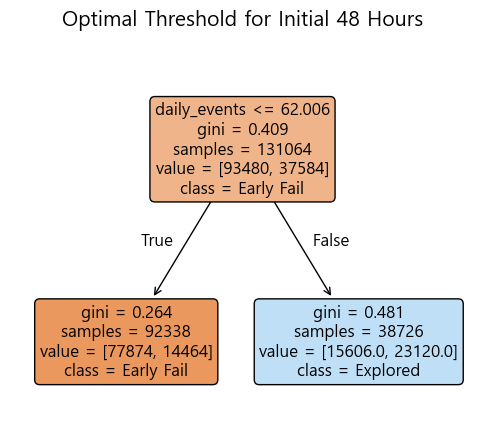

In [17]:
from sklearn.tree import DecisionTreeClassifier
import graphviz

# 2일 안에 이탈한 사람, explored까지 도달한 사람
df_tmp = pd.concat([df_suc_explored, df_2day], axis = 0)
df_tmp = df_tmp[df_tmp['daily_events'].notna()]

X = df_tmp[['daily_events']]
y = df_tmp['explored']

tree_model = DecisionTreeClassifier(max_depth = 1)
tree_model.fit(X,y)

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(6, 5)) # 그래프 크기 설정

# plot_tree 함수로 한 방에 그리기
plot_tree(
    tree_model,
    feature_names=['daily_events'],
    class_names=['Early Fail', 'Explored'],
    filled=True,
    rounded=True,
    fontsize=12 # 글자 크기
)

plt.title('Optimal Threshold for Initial 48 Hours', fontsize=15, pad=20)
plt.show()

In [18]:
# 수료자 그룹은 4.59일에 1번씩 접속하는 것을 알 수 있음
(df_suc_explored['duration'] + 1).sum() / df_suc_explored['ndays_act'].sum()

np.float64(4.589706475300672)

In [19]:
# 흐흐
62.006 / 4.59 * 2

27.01786492374728

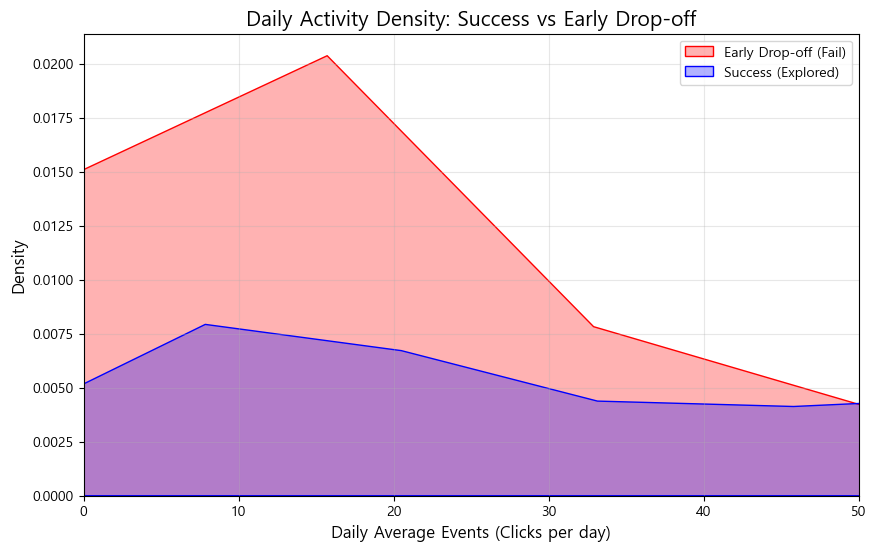

In [20]:
# 밀도 기반 분기점 그래프 -> 교차하는 지점을 찾아보려 했는데, 쉽지 않네요
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_2day, x='daily_events', color='red', fill=True, alpha=0.3, label='Early Drop-off (Fail)')
sns.kdeplot(data=df_suc_explored, x='daily_events', color='blue', fill=True, alpha=0.3, label='Success (Explored)')

plt.title('Daily Activity Density: Success vs Early Drop-off', fontsize=15)
plt.xlabel('Daily Average Events (Clicks per day)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 50) 
plt.legend()
plt.grid(alpha=0.3)
plt.show()

인구 통계 정보 확인

In [26]:
df_2day_under = df_fail_explored[df_fail_explored['duration'] <= 2]
df_2day_over = df_fail_explored[df_fail_explored['duration'] > 2]

In [32]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. 분석을 위한 데이터 준비 (두 그룹에 라벨 달아주기)
df_2day_under['group'] = 'Early (<=2d)'
df_2day_over['group'] = 'Later (>2d)'

# 두 데이터를 하나로 합칩니다.
df_combined = pd.concat([df_2day_under, df_2day_over])

# 2. 교차표(Contingency Table) 만들기
# 행은 그룹(초기/후기), 열은 학력(LoE_DI)으로 설정
ct = pd.crosstab(df_combined['group'], df_combined['LoE_DI'])

print("▼ 교차표 (빈도수) ▼")
display(ct)

# 3. 카이제곱 검정 실시
chi2, p, dof, expected = chi2_contingency(ct)

print(f"\n카이제곱 통계량: {chi2:.4f}")
print(f"P-value: {p:.4f}")

# 4. 결과 해석
alpha = 0.05
if p < alpha:
    print("\n✅ 결과: P-value가 0.05보다 작으므로, 두 그룹 간 학력 분포에 '유의미한 차이'가 있습니다.")
    print("즉, 이탈 시점(초기 vs 후기)에 따라 특정 학력층의 비중이 다릅니다.")
else:
    print("\n❌ 결과: P-value가 0.05보다 크므로, 두 그룹 간 학력 분포 차이는 통계적으로 유의미하지 않습니다.")
    print("이탈 시점은 학력과 관계없이 무작위로 일어난다고 볼 수 있습니다.")

▼ 교차표 (빈도수) ▼


LoE_DI,Bachelor's,Doctorate,Less than Secondary,Master's,Secondary,unknown
group,,,,,,
Early (<=2d),32794,2115,2456,16500,27200,14222
Later (>2d),62334,4319,4237,36108,48942,36550



카이제곱 통계량: 1021.8623
P-value: 0.0000

✅ 결과: P-value가 0.05보다 작으므로, 두 그룹 간 학력 분포에 '유의미한 차이'가 있습니다.
즉, 이탈 시점(초기 vs 후기)에 따라 특정 학력층의 비중이 다릅니다.


[[32794  2115  2456 16500 27200 14222]
 [62334  4319  4237 36108 48942 36550]]


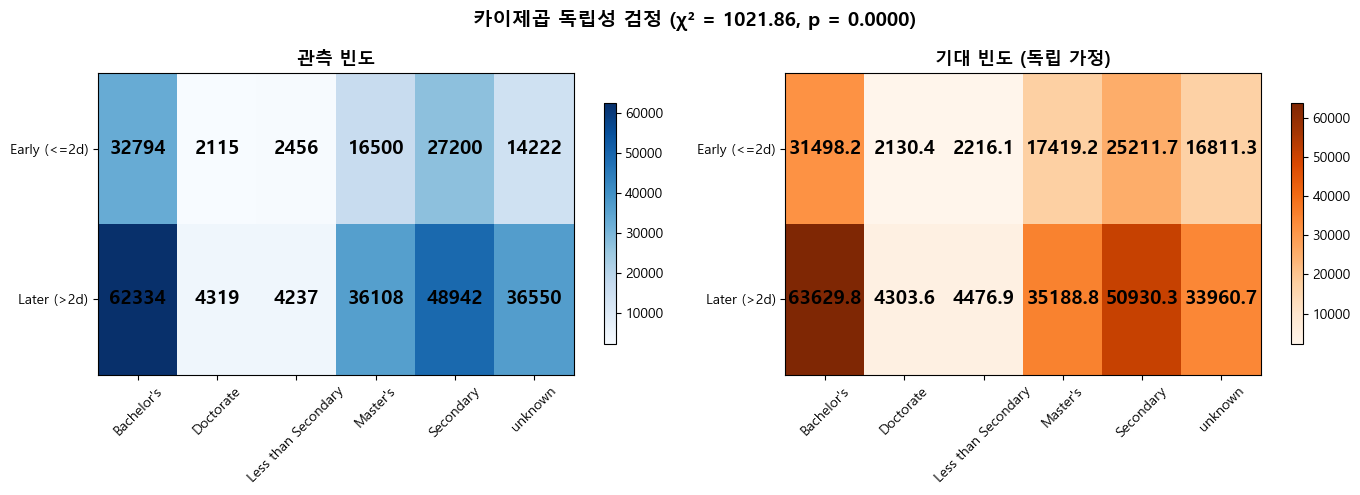

In [36]:
#### 무아 튜터님 자료 그대로 복붙(솔직하게 보고용 이쁘게 만든 자료. 필요없긴함)
# ── 시각화: 교차표 히트맵 ──
# 관측 빈도 히트맵
ct_raw = ct
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ct_obs, cmap='Blues', aspect='auto')
axes[0].set_title('관측 빈도', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(ct_raw.columns)))
axes[0].set_xticklabels(ct_raw.columns, rotation = 45)
axes[0].set_yticks(range(len(ct_raw.index)))
axes[0].set_yticklabels(ct_raw.index)
for i in range(ct_obs.shape[0]):
    for j in range(ct_obs.shape[1]):
        axes[0].text(j, i, f'{ct_obs[i, j]}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 기대 빈도 히트맵
im2 = axes[1].imshow(expected, cmap='Oranges', aspect='auto')
axes[1].set_title('기대 빈도 (독립 가정)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(ct.columns)))
axes[1].set_xticklabels(ct_raw.columns, rotation = 45)
axes[1].set_yticks(range(len(ct.index)))
axes[1].set_yticklabels(ct.index)
for i in range(expected.shape[0]):
    for j in range(expected.shape[1]):
        axes[1].text(j, i, f'{expected[i, j]:.1f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

fig.suptitle(f"카이제곱 독립성 검정 (χ² = {chi2:.2f}, p = {p:.4f})",
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 효과 크기가 그렇게 크지 않음.
# 결국, viewed <= 2와 viewed > 2 집단에서의 차이가 크지 않다는 얘기
from scipy.stats.contingency import association

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')


검정의 효과크기 : 0.0596


In [ ]:
# 인구 정보 결측 정도가 크게 유의미하지는 않은 것 같음.
df_2day[(df_2day['LoE_DI'].isna()) | (df_2day['age'].isna()) | (df_2day['gender'].isna())]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num,daily_events
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,...,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN,32.0
10,HarvardX/CS50x/2012,MHxPC130094371,1,1,0,0,United States,unknown,NaN,unknown,...,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN,7.0
28,HarvardX/ER22x/2013_Spring,MHxPC130393660,1,1,0,0,United States,unknown,NaN,unknown,...,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN,15.0
52,HarvardX/CB22x/2013_Spring,MHxPC130498347,1,1,0,0,Japan,unknown,NaN,unknown,...,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN,29.0
55,HarvardX/CS50x/2012,MHxPC130541204,1,1,0,0,United States,unknown,NaN,unknown,...,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533834,MITx/6.00x/2013_Spring,MHxPC130258677,1,1,0,0,United States,unknown,NaN,unknown,...,NaN,True,False,NaN,NaN,NaN,unknown,0,NaN,133.0
533846,MITx/8.02x/2013_Spring,MHxPC130477141,1,1,0,0,United States,unknown,NaN,m,...,NaN,True,False,NaN,NaN,NaN,unknown,0,NaN,40.0
533875,MITx/6.00x/2013_Spring,MHxPC130210662,1,1,0,0,United States,Master's,NaN,unknown,...,NaN,True,False,NaN,NaN,NaN,unknown,0,4.0,9.0
533878,MITx/8.MReV/2013_Summer,MHxPC130304103,1,1,0,0,India,unknown,NaN,m,...,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN,109.0


In [ ]:
# 혹시 몰라서 봤는데, Unknown 국가는 안 될 것 같음
df_2day['final_cc_cname_DI'].value_counts()

final_cc_cname_DI
United States                             29320
India                                     15853
Other Europe                               6875
Other Africa                               4080
United Kingdom                             3736
Other Middle East/Central Asia             3186
Brazil                                     3142
Other South Asia                           2374
Canada                                     2004
Pakistan                                   1715
Other South America                        1710
Other East Asia                            1584
Unknown/Other                              1500
China                                      1493
Germany                                    1469
Egypt                                      1431
Spain                                      1341
Russian Federation                         1199
Morocco                                    1177
Poland                                     1087
Nigeria               

In [ ]:
df_suc_explored['daily_events']

▼ 하루 평균 활동량(구간)에 따른 수료 확률 변화 ▼


,activity_tier,explored
0,"(0.249, 7.0]",10.023932
1,"(7.0, 15.0]",16.224075
2,"(15.0, 37.642]",15.032881
3,"(37.642, 93.0]",38.615783
4,"(93.0, 3383.0]",64.259486


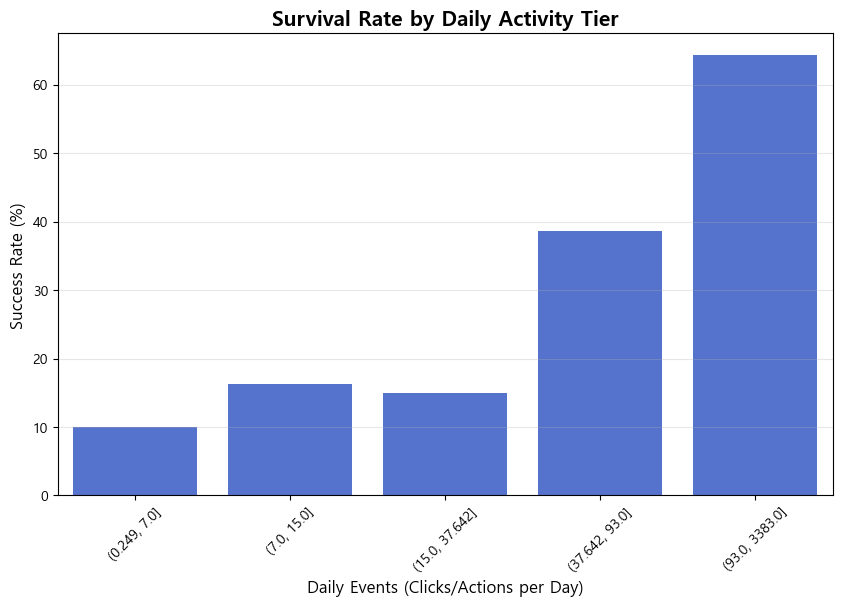

In [15]:
df_2day['daily_events'] =  df_2day['nevents'] / df_2day['ndays_act']
df_fail_explored['daily_events'] = df_fail_explored['nevents'] / df_fail_explored['ndays_act']
df_suc_explored['daily_events'] = df_suc_explored['nevents'] / df_suc_explored['ndays_act']

# 1. 성공 그룹과 초기 이탈 그룹 데이터 합치기
df_compare = pd.concat([df_suc_explored, df_2day])

# 2. 하루 평균 클릭수(daily_events)를 5개의 등급(티어)으로 쪼개기
# qcut은 인원수를 비슷하게 5등분 해줍니다. (데이터에 따라 q=5, 10 조절)
df_compare['activity_tier'] = pd.qcut(df_compare['daily_events'], q=5, duplicates='drop')

# 3. 각 티어별 평균 수료율(Explored 확률) 계산
conversion_rates = df_compare.groupby('activity_tier')['explored'].mean() * 100

print("▼ 하루 평균 활동량(구간)에 따른 수료 확률 변화 ▼")
display(conversion_rates.reset_index())

# 4. 시각화 (수료율이 폭등하는 '계단' 찾기)
plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_rates.index.astype(str), y=conversion_rates.values, color='royalblue')

plt.title('Survival Rate by Daily Activity Tier', fontsize=15, fontweight='bold')
plt.xlabel('Daily Events (Clicks/Actions per Day)', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2. 중기 이탈 구간

특정 유저들의 이탈과 50% 이상 수강하는 유저의 비율이 동일해지는 구간을 찾는다면,

그 때까지 유저의 접속을 유지시켜야 한다는 근거가 되지 않을까.
+) 활동까지

explored에 도달하기 까지 유저의 활동을 어디까지 이끌어야하는지에 대해서 explored의 proportion을 그려봄.

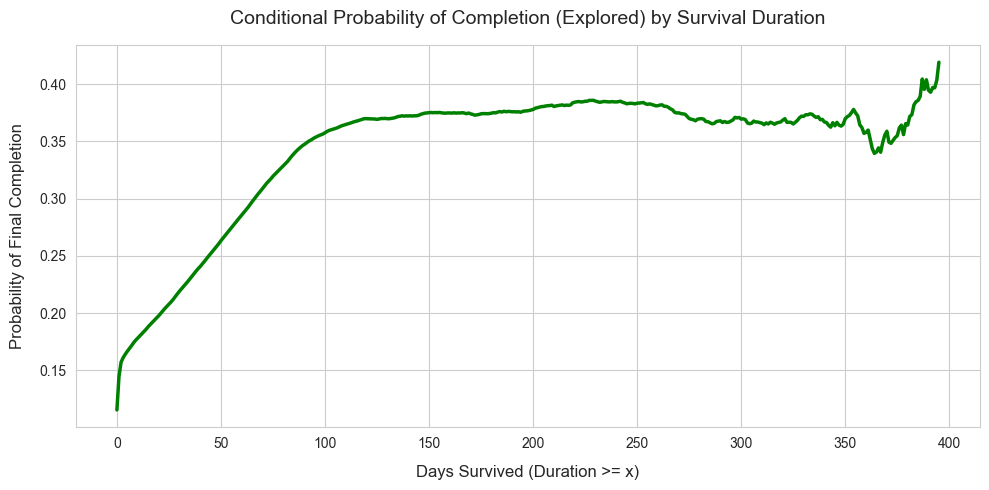

In [14]:
conditional_results = []
max_days = int(df_viewed['duration'].max())

# x일보다 적은 구간은 제외하면서 그래프를 그려봄
for x in range(max_days + 1):
    survivors = df_viewed[df_viewed['duration'] >= x]

    if len(survivors) > 100:
        success_count = survivors['explored'].sum()
        prob = success_count / len(survivors)

        conditional_results.append({'day' : x, 'cond_prob': prob, 'sample_size': len(survivors)})
df_cond = pd.DataFrame(conditional_results)


plt.figure(figsize=(10, 5))
sns.set_style("whitegrid") 

sns.lineplot(data=df_cond, x='day', y='cond_prob', color='green', linewidth=2.5)

plt.title('Conditional Probability of Completion (Explored) by Survival Duration', fontsize=14, pad=15)
plt.xlabel('Days Survived (Duration >= x)', fontsize=12, labelpad=10)
plt.ylabel('Probability of Final Completion', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

x일 이상의 데이터에서 explored의 비율을 계산했을 때의 결과.

-> 수료 즈음까지 120일 가량을 접속하게 끔 해야, 35%의 유저가 explored에 도달할 수 있다고 추측할 수 있는 근거가 되지 않을까.

In [13]:
df_viewed.columns

Index(['course_id', 'userid_DI', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade',
       'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'viewed_missing_flag', 'duration',
       'fast_completion_flag', 'start_year', 'age_raw', 'age_missing_original',
       'age_invalid', 'age_cleaned', 'age_final', 'age', 'age_group',
       'exam_flag', 'LoE_num'],
      dtype='str')

### Appendix. 강의 별 챕터 확인 사항

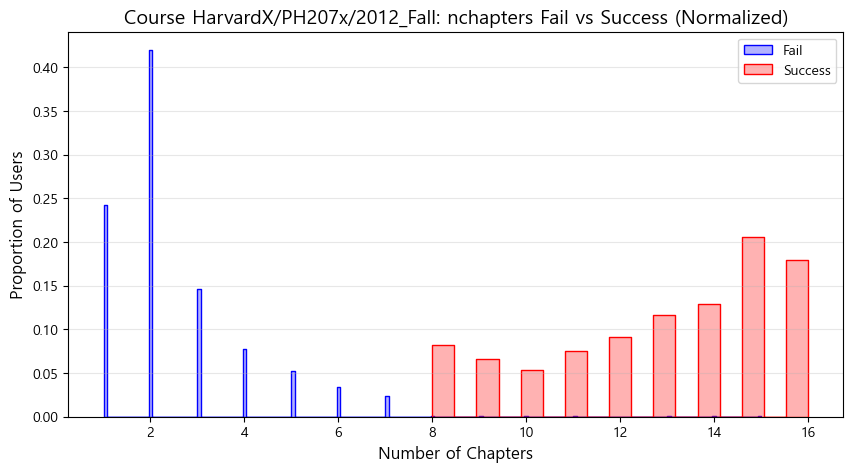

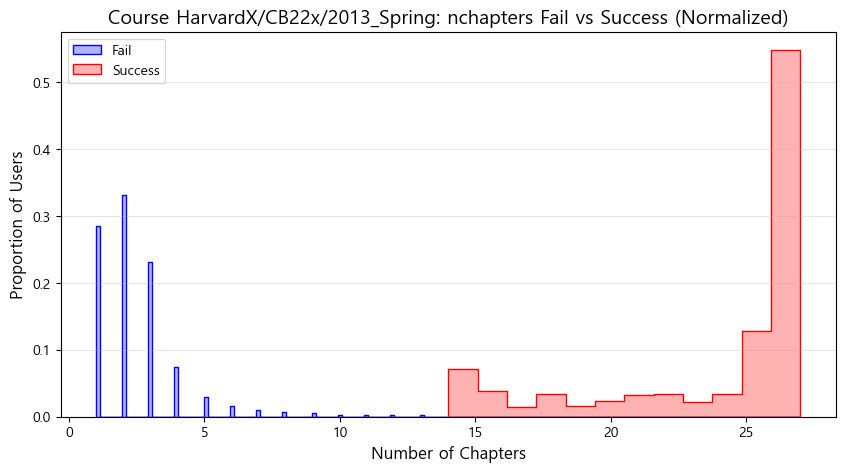

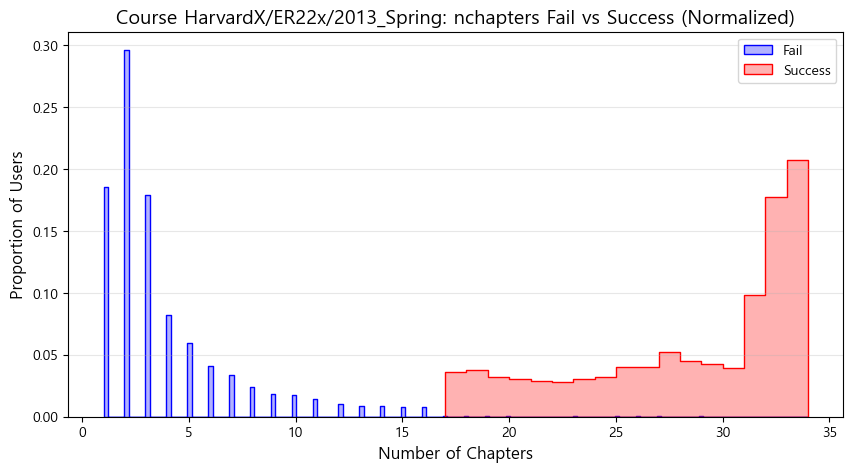

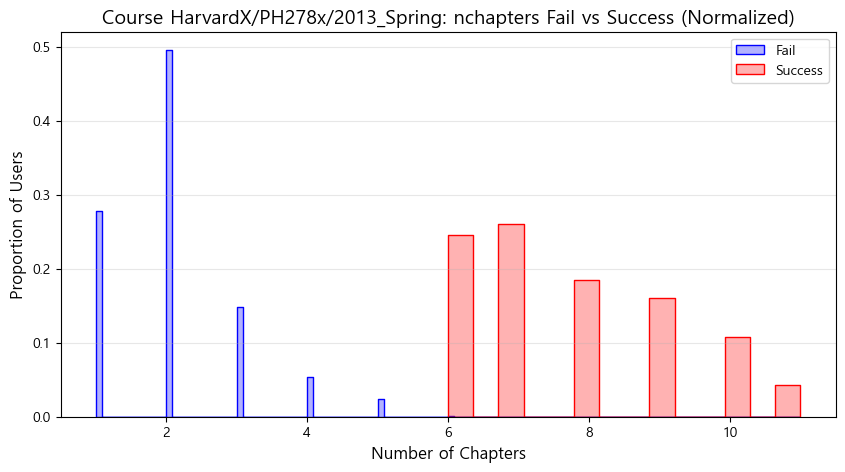

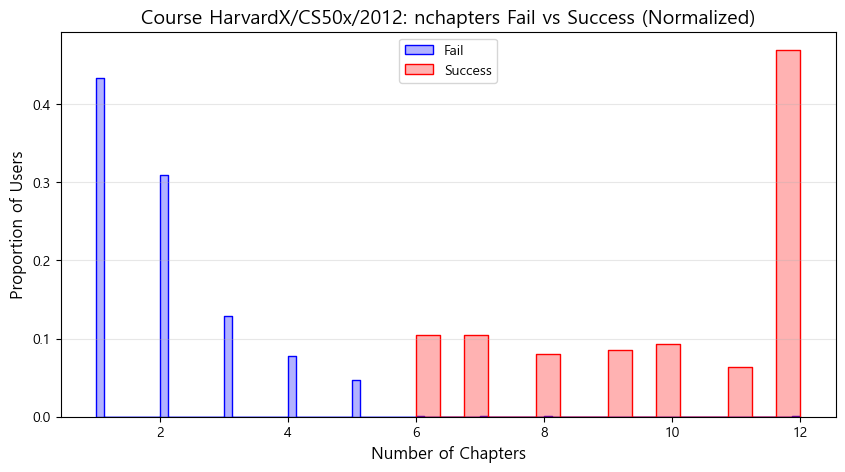

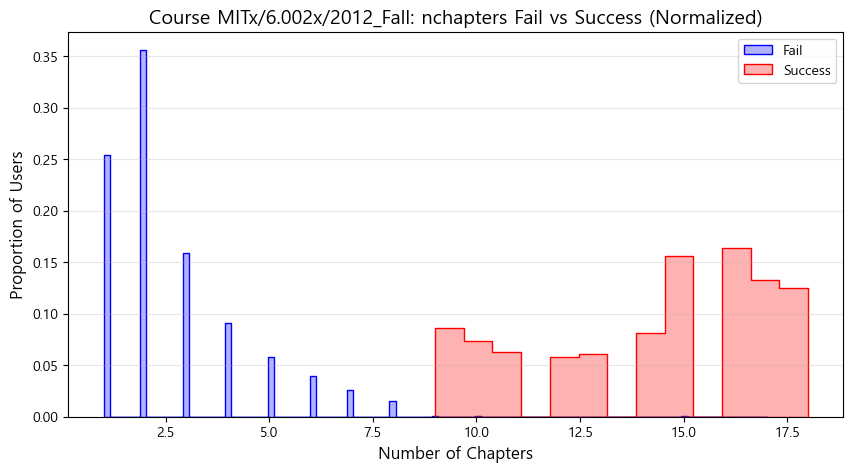

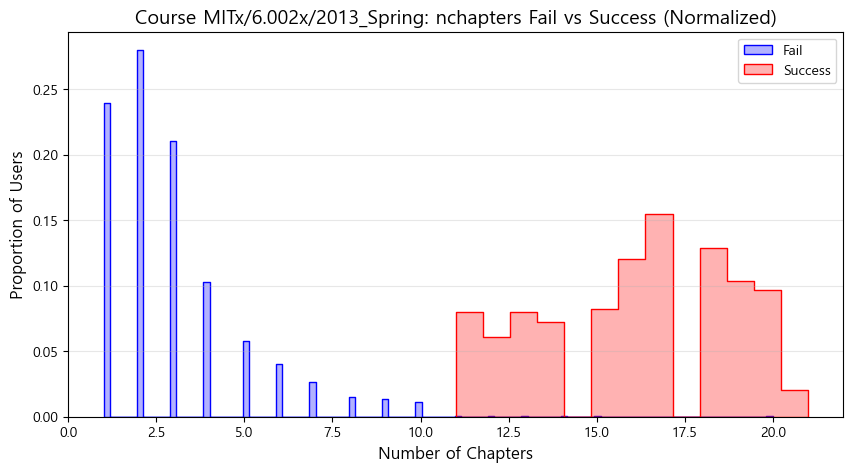

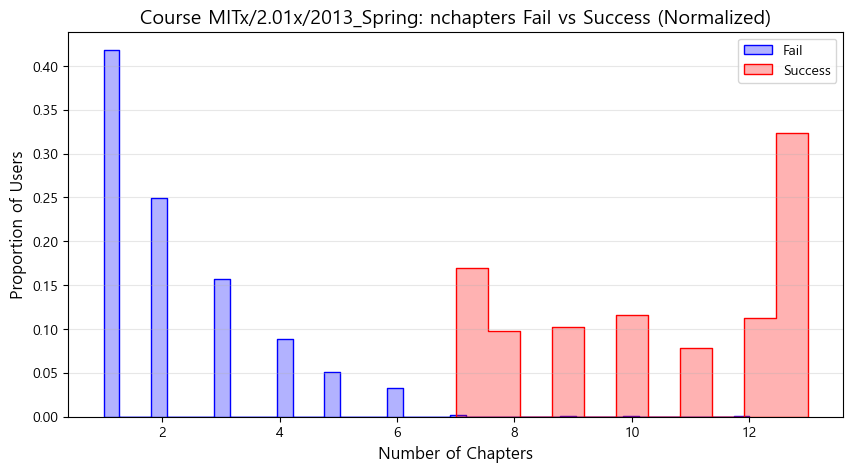

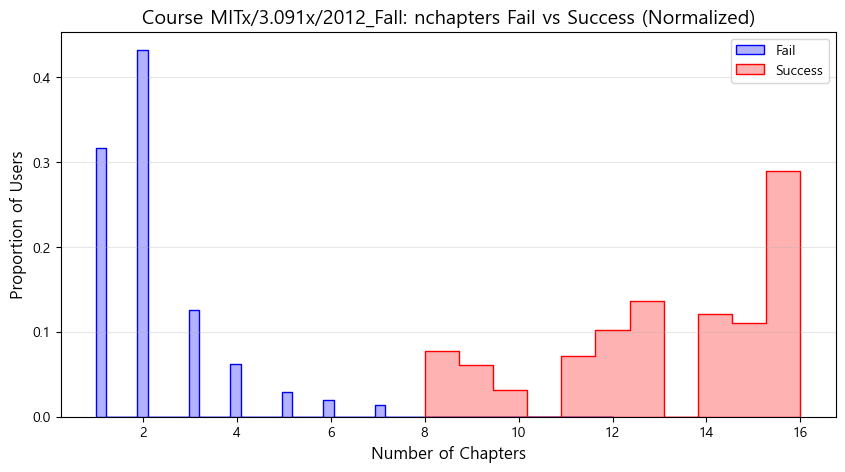

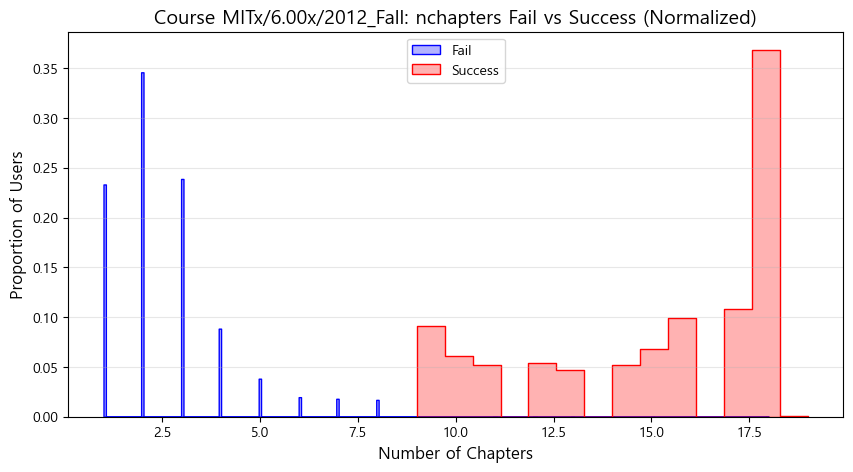

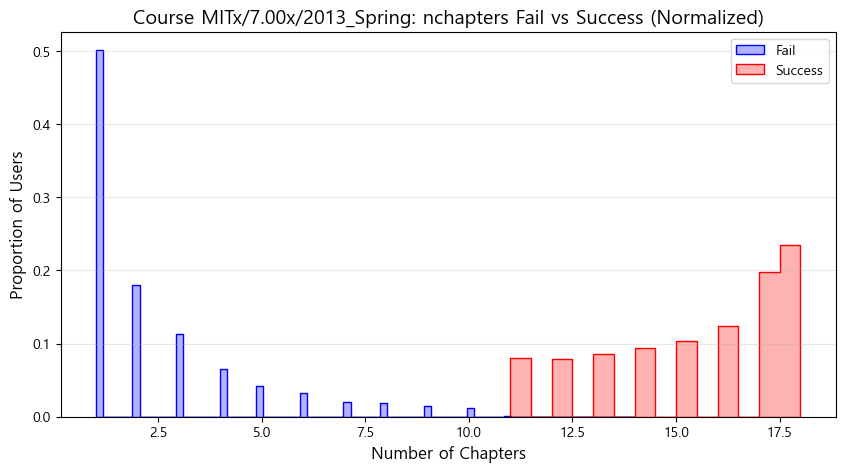

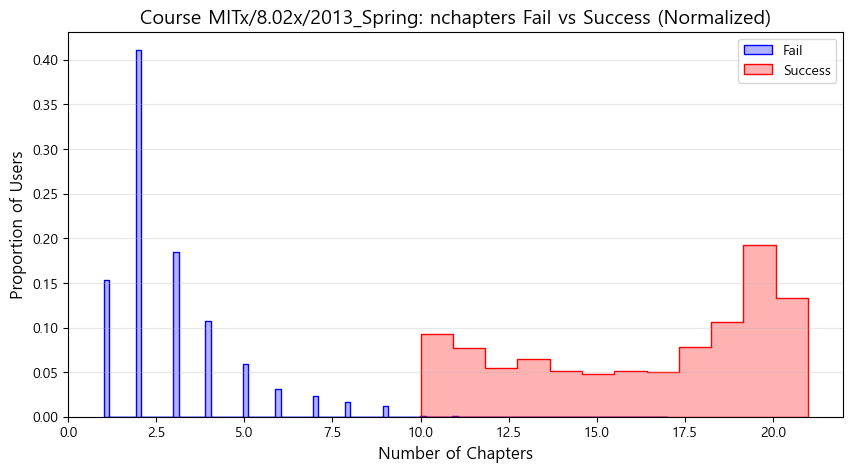

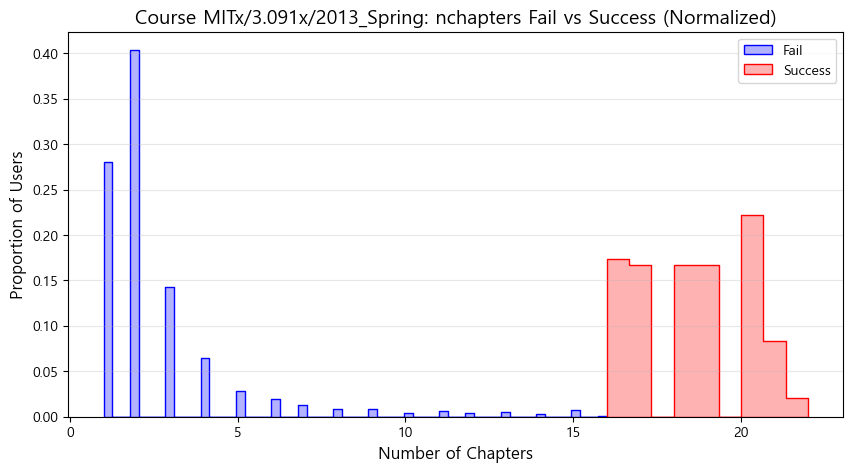

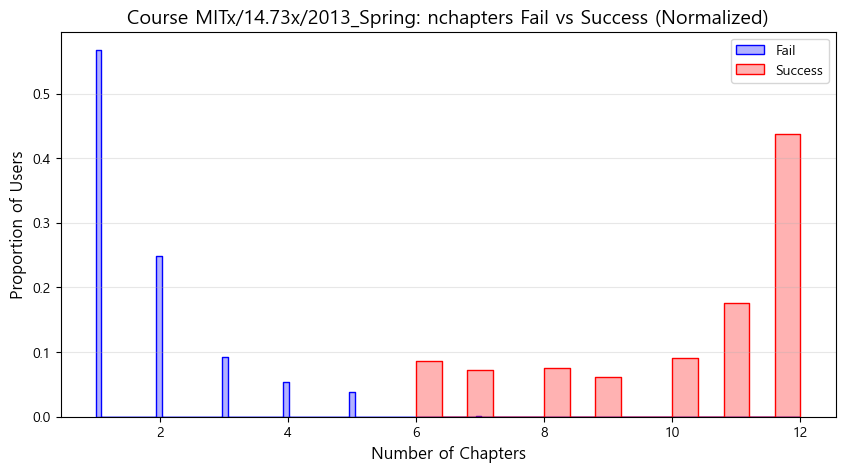

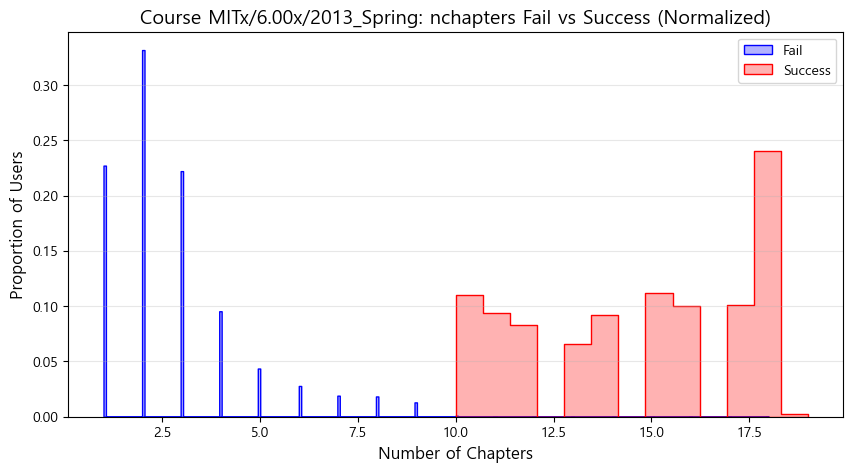

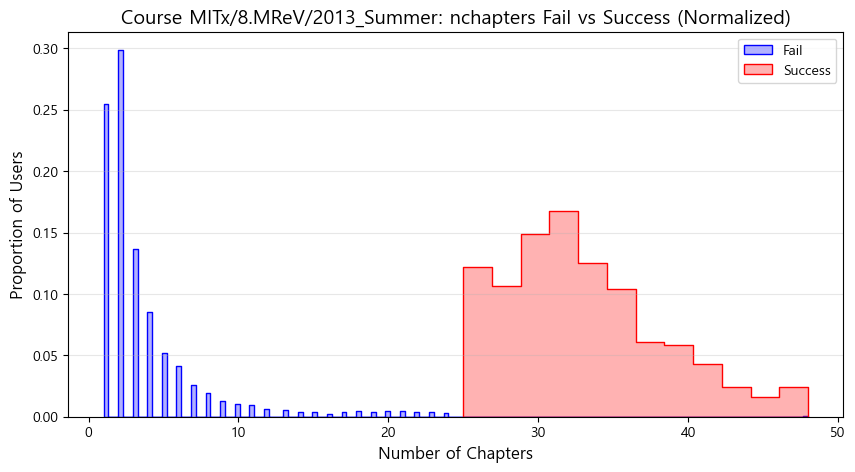

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

course = df_viewed['course_id'].unique()

for c in course:
    # 1. 해당 코스의 데이터 필터링
    data_fail = df_fail_explored.loc[df_fail_explored['course_id'] == c, 'nchapters']
    data_suc = df_suc_explored.loc[df_suc_explored['course_id'] == c, 'nchapters']
    
    if data_fail.empty and data_suc.empty:
        continue

    plt.figure(figsize=(10, 5))
    
    # 2. 핵심 옵션 추가: 
    # stat='proportion' -> y축을 인원수(Count)가 아닌 비율(0~1)로 통일 (체급 맞추기)
    # alpha=0.3 -> 투명도를 30%로 설정 (겹쳐 보이게 만들기)
    # common_norm=False -> 각 그룹 안에서 비율 합이 1이 되도록 설정 (중요!)
    
    sns.histplot(data=data_fail, color='blue', label='Fail', 
                 stat='proportion', common_norm=False, alpha=0.3, element="step")
    
    sns.histplot(data=data_suc, color='red', label='Success', 
                 stat='proportion', common_norm=False, alpha=0.3, element="step")
    
    plt.title(f'Course {c}: nchapters Fail vs Success (Normalized)', fontsize=14)
    plt.xlabel('Number of Chapters', fontsize=12)
    plt.ylabel('Proportion of Users', fontsize=12) # Y축이 이제 비율로 바뀝니다.
    plt.legend()
    plt.grid(axis='y', alpha=0.3) # 그리드 추가해서 가독성 높이기
    plt.show()